In [15]:
# ENVIRONMENT SETUP (DEPENDENCY MANAGEMENT)
# INSTALLING EXTERNAL PACKAGE: WORDCLOUD
# "--quiet" REDUCES TERMINAL NOISE FOR CLEANER NOTEBOOK OUTPUT
# WHY:
# 1. GUARANTEES REPRODUCIBILITY ACROSS DIFFERENT MACHINES / RUNTIMES
# 2.  PREVENTS IMPORT FAILURES LATER IN THE PIPELINE
!pip install wordcloud --quiet
# IMPORTING NLTK LIBRARY FOR NATURAL LANGUAGE PROCESSING UTILITIES
import nltk
# DOWNLOADING STOPWORDS CORPUS FROM NLTK
# STOPWORDS ARE HIGH-FREQUENCY, LOW-INFORMATION WORDS (THE, AND, BUT, ...)
# "quiet=True" SUPPRESSES DOWNLOAD LOG OUTPUT
# WHY:
# 1. STOPWORD REMOVAL IS A STANDARD PREPROCESSING STEP
# 2. IMPROVES QUALITY OF FREQUENCY-BASED ANALYSIS AND VISUALIZATIONS
nltk.download('stopwords', quiet=True)
# CONFIRM SETUP COMPLETED SUCCESSFULLY
print("SETUP OF wordcloud, nltk, AND stopwords COMPLETE")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
SETUP OF wordcloud, nltk, AND stopwords COMPLETE


In [16]:
# CORE TEXT PROCESSING UTILITIES
import re           # REGULAR EXPRESSIONS FOR TEXT CLEANING AND PATTERN MATCHING
import string       # STRING MODULE FOR ACCESS TO CONSTANTS LIKE PUNCTUATION
import math         # MATHEMATICAL OPERATIONS TO SUPPORT FEATURE ENGINEERING
import collections  # COLLECTIONS MODULE FOR SPECIALIZED DATA STRUCTURES
from collections import Counter # COUNTING TOKEN FREQUENCIES IN "BAG-OF-WORDS"
import itertools    # ITERATION UTILITIES TO GENERATE N-GRAMS W/O NESTED LOOPS

# ORGANIZES TEXT DATA, METADATA, AND DERIVED FEATURES FOR STRUCTURED ANALYSIS
import pandas as pd

# EXPLORATORY DATA ANALYSIS AND VISUALIZATION
import matplotlib.pyplot as plt     # FOR PLOTTING DISTRIBUTIONS (WORD COUNTS)
import matplotlib.ticker as ticker  # AXIS CUSTOMIZATION (IMPROVES READABILITY)

# NLP VISUALIZATION + PREPROCESSING COMPONENTS
from wordcloud import WordCloud     # VISUALIZING WORD FREQUENCY DISTRIBUTIONS
from nltk.corpus import stopwords   # USED FOR "NOISE" REDUCTION (stopwords)

# FINAL CONFIRMATION THAT ALL IMPORTS SUCCEEDED
print("ALL IMPORTS SUCCESSFUL")

ALL IMPORTS SUCCESSFUL


In [17]:
# STORING SOURCE METADATA FOR TRACEABILITY AND REPRODUCIBILITY
# WHY:
# 1. SUPPORTS ACADEMIC TRANSPARENCY AND REPRODUCIBILITY
# 2. MAKES IT EASY TO VERIFY OR SWAP DATA SOURCES LATER
NOVEL_URL    = "https://www.gutenberg.org/files/28054/28054-0.txt"
NOVEL_TITLE  = "The Brothers Karamazov"
NOVEL_AUTHOR = "Fyodor Dostoevsky (tr. Constance Garnett)"
# DOWNLOADING RAW TEXT FILE FROM PROJECT GUTENBERG
# "-q" SUPPRESSES OUTPUT FOR CLEANER NOTEBOOK DISPLAY
# "-O karamazov.txt" SPECIFIES THE LOCAL OUTPUT FILE NAME
# WHY:
# 1. AUTOMATES DATA INGESTION (NO MANUAL DOWNLOAD REQUIRED)
# 2. ENSURES CONSISTENT INPUT DATA ACROSS EXECUTIONS
!wget -q -O karamazov.txt {NOVEL_URL}

# CHECKPOINT TO CONFIRM DOWNLOAD COMPLETED
print("DOWNLOAD COMPLETE")

def loadGutenText(filepath):
    """
    READS LOCALLY SAVED PROJECT GUTENBERG PLAIN-TEXT FILE AND STRIPS THE STANDARD GUTENBERG HEADER AND FOOTER BOILERPLATE, RETURNING ONLY THE BODY OF THE WORK.
    ARGS:
        filepath (str): PATH TO THE DOWNLOADED .txt FILE
    RETURNS:
        str: RAW NOVEL TEXT WITH GUTENBERG METADATA REMOVED
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS IN FILE
    """
    # OPEN FILE USING UTF-8 ENCODING
    # errors='replace' HANDLES INVALID CHARACTERS WITHOUT RAISING EXCEPTIONS
    # WHY:
    # 1. REAL-WORLD TEXT DATA OFTEN CONTAINS ENCODING IRREGULARITIES
    # 2. PREVENTS PIPELINE FAILURE DURING FILE READ
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        raw = f.read()
    # DEFINING GUTENBERG HEADER/FOOTER MARKERS
    # THESE DELIMIT THE NON-CONTENT METADATA FROM THE ACTUAL TEXT
    startMarker = "*** START OF"
    endMarker   = "*** END OF"
    # FINDING START OF ACTUAL NOVEL TEXT
    # .find() RETURNS INDEX OF FIRST MATCH OR -1 IF NOT FOUND
    startIndex = raw.find(startMarker)
    if startIndex != -1:
        # MOVE TO FIRST CHARACTER AFTER THE HEADER LINE
        # ENSURES WE SKIP GUTENBERG METADATA CLEANLY
        startIndex = raw.find('\n', startIndex) + 1
    else:
        startIndex = 0  # IF MARKER IS MISSING, START FROM BEGINNING
    # FINDING END OF NOVEL TEXT
    endIndex = raw.find(endMarker)
    if endIndex == -1:
        # IF END MARKER IS MISSING, USE FULL FILE; NO DATA LOSS IN EDGE CASE
        endIndex = len(raw)
    # EXTRACTING ONLY THE CLEAN TEXT BODY
    # .strip() REMOVES LEADING/TRAILING WHITESPACE
    # WHY:
    # 1. REMOVES NON-CONTENT TEXT THAT WOULD SKEW ANALYSIS
    # 2. ENSURES DOWNSTREAM NLP OPERATES ON TRUE CORPUS DATA
    return raw[startIndex:endIndex].strip()

# LOADING AND CLEANING THE DOWNLOADED TEXT
# RAW NOVEL TEXT WITH GUTENBERG METADATA REMOVED
rawText = loadGutenText("karamazov.txt")

# PRINTING METADATA FOR VERIFICATION; CONFIRMS WORKING WITH EXPECTED SOURCE
print(f"NOVEL:  {NOVEL_TITLE}")
print(f"AUTHOR: {NOVEL_AUTHOR}")
print(f"SOURCE: {NOVEL_URL}")

# CHARACTER COUNT TO DETECT TRUNCATION OR FAILED DOWNLOADS
# WHY: SMALL SIZE CAN SIGNAL DATA ISSUES EARLY
print(f"\nRAW CHARACTER COUNT: {len(rawText):,}")

# DISPLAY FIRST 400 CHARACTERS AS A SANITY CHECK
# ALLOWS VISUAL CONFIRMATION THAT:
# 1. HEADER/FOOTER WERE REMOVED
# 2. TEXT LOOKS CLEAN (NO ENCODING ISSUES OR GARBAGE TOKENS)
print(f"\n--- FIRST 400 CHARS (SANITY CHECK)")
print(rawText[:400])

DOWNLOAD COMPLETE
NOVEL:  The Brothers Karamazov
AUTHOR: Fyodor Dostoevsky (tr. Constance Garnett)
SOURCE: https://www.gutenberg.org/files/28054/28054-0.txt

RAW CHARACTER COUNT: 1,935,357

--- FIRST 400 CHARS (SANITY CHECK)
The Brothers Karamazov

Translated from the Russian of

Fyodor Dostoyevsky

by Constance Garnett

The Lowell Press

New York


Contents

 Part I
 Book I. The History Of A Family
 Chapter I. Fyodor Pavlovitch Karamazov
 Chapter II. He Gets Rid Of His Eldest Son
 Chapter III. The Second Marriage And The Second Family
 Chapter IV. The Third Son, Alyosha
 Chapter V. Elders
 Book II. An Unfortunate Gat


In [18]:
# DEFINING STOPWORD SET USING NLTK CORPUS
# CONVERTING TO A SET FOR O(1) CHECKS DURING FILTERING
# WHY:
# 1. LIST LOOKUPS ARE O(n), SET LOOKUPS ARE O(1)
# 2. CRITICAL FOR PERFORMANCE WHEN PROCESSING LARGE CORPORA
STOPWORDS = set(stopwords.words('english'))

def toLower(text):
    """
    CONVERTS ALL CHARACTERS IN text TO LOWERCASE.
    ARGS:
        text (str): RAW INPUT TEXT
    RETURNS:
        str: FULLY LOWERCASE TEXT
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS
    """
    # NORMALIZING TEXT TO LOWERCASE
    # REDUCES FEATURE SPACE BY MERGING CASE VARIANTS (E.G., "The" vs "the")
    # WHY:
    # 1. PREVENTS ARTIFICIAL DUPLICATION OF TOKENS
    # 2. STANDARD PRACTICE IN NLP PREPROCESSING PIPELINES
    return text.lower()

def removePunctuation(text, keepApostrophes=True):
    """
    REMOVES PUNCTUATION, DIGITS, AND SPECIAL CHARACTERS FROM TEXT.
    BY DEFAULT, PRESERVES APOSTROPHES THAT APPEAR BETWEEN TWO LOWERCASE
    LETTERS ("DON'T", "IVAN'S"); LEADING OR TRAILING APOSTROPHES
    ARE STRIPPED.
    ARGS:
        text             (str):  LOWERCASED INPUT TEXT
        keepApostrophes  (bool): IF TRUE, KEEP INTRA-WORD APOSTROPHES
    RETURNS:
        str: CLEANED TEXT CONTAINING ONLY LETTERS, SPACES, AND
             (OPTIONALLY) INTRA-WORD APOSTROPHES
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS
    """
    if keepApostrophes:
        # PROTECTING INTRA-WORD APOSTROPHES USING LOOKAROUND REGEX
        # (?<=[a-z])  PRECEDED BY LOWERCASE LETTER
        # (?=[a-z])   FOLLOWED BY LOWERCASE LETTER
        # TEMPORARILY REPLACING VALID APOSTROPHES WITH TEMP TOKEN ("APOS")
        # WHY:
        # 1. PRESERVES SEMANTICALLY MEANINGFUL TOKENS LIKE "DON'T", "IVAN'S"
        # 2. AVOIDS BREAKING WORDS INTO INVALID FRAGMENTS ("don", "t")
        text = re.sub(r"(?<=[a-z])'(?=[a-z])", "APOS", text)
    # REMOVING ALL NON-LETTER CHARACTERS (EXCEPT WHITESPACE AND TEMP TOKEN)
    # [^a-z\sAPOS] → KEEP ONLY LOWERCASE LETTERS, SPACES, AND "APOS"
    # EVERYTHING ELSE (PUNCTUATION, DIGITS, SYMBOLS) IS REPLACED WITH SPACE
    # WHY:
    # 1. ELIMINATES NOISE THAT DOES NOT CONTRIBUTE TO SEMANTIC ANALYSIS
    # 2. STANDARDIZES INPUT FOR TOKENIZATION
    text = re.sub(r"[^a-z\sAPOS]", " ", text)
    if keepApostrophes:
        # RESTORING ORIGINAL APOSTROPHES FROM APOS TOKEN
        text = text.replace("APOS", "'")
    # COLLAPSING MULTIPLE SPACES INTO A SINGLE SPACE
    # PREVENTS EMPTY TOKENS DURING SPLIT
    # WHY: ENSURES CLEAN TOKENIZATION STEP (NO "" TOKENS)
    text = re.sub(r" {2,}", " ", text)
    return text

def tokenize(text):
    """
    SPLITS CLEANED TEXT ON WHITESPACE AND FILTERS OUT TOKENS THAT ARE
    A SINGLE CHARACTER OR EMPTY.
    ARGS:
        text (str): CLEANED, LOWERCASED INPUT TEXT
    RETURNS:
        list[str]: LIST OF WORD TOKENS WITH LENGTH >= 2
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS
    """
    # SPLITTING TEXT INTO TOKENS USING WHITESPACE DELIMITER
    # THEN FILTERING TOKENS WITH LENGTH > 1
    # WHY:
    # 1. REMOVES LOW-INFORMATION TOKENS (a, i, etc.) THAT ADD NOISE
    # 2. REDUCES DIMENSIONALITY OF TOKEN SPACE
    # NOTE: THIS IS A DESIGN CHOICE — SINGLE-CHAR TOKENS CAN BE RETAINED IN OTHER CONTEXTS
    return [w for w in text.split() if len(w) > 1]

def removeStopwords(tokens, stopwordSet=STOPWORDS):
    """
    FILTERS A TOKEN LIST BY REMOVING ANY TOKEN PRESENT IN THE PROVIDED
    STOPWORD SET.
    ARGS:
        tokens      (list[str]): LIST OF WORD TOKENS TO BE FILTERED
        stopwordSet (set):       SET OF STOPWORDS TO EXCLUDE
    RETURNS:
        list[str]: TOKENS WITH ALL STOPWORDS REMOVED
    BIG-O: O(w) WHERE w = NUMBER OF TOKENS — SET LOOKUP IS O(1) PER TOKEN
    """
    # FILTERING TOKENS USING SET MEMBERSHIP CHECK
    # EACH TOKEN IS INCLUDED ONLY IF NOT IN STOPWORD SET
    # WHY:
    # 1. REMOVES HIGH-FREQUENCY, LOW-INFORMATION WORDS
    # 2. IMPROVES SIGNAL-TO-NOISE RATIO IN ANALYSIS
    # 3. ESSENTIAL FOR METHODS LIKE WORD FREQUENCY ANALYSIS AND WORDCLOUDS
    return [w for w in tokens if w not in stopwordSet]


def preprocess(text, stopwordSet=STOPWORDS):
    """
    FULL PREPROCESSING PIPELINE IN FOUR STEPS
        1. LOWERCASE
        2. REMOVE PUNCTUATION (KEEPING INTRA-WORD APOSTROPHES)
        3. TOKENIZE USING WHITESPACE
        4. REMOVE STOPWORDS
    ARGS:
        text (str): RAW NOVEL TEXT TO BE PROCESSED
        stopwordSet (set): SET OF STOPWORDS TO REMOVE (DEFAULT: NLTK ENGLISH)
    RETURNS:
        tuple:
            lowercased  (str)        -AFTER STEP 1
            rawTokens   (list[str])  -AFTER STEP 3, BEFORE STEP 4
            cleanTokens (list[str])  -AFTER STEP 4
    BIG-O: O(n) OVERALL, DOMINATED BY CHARACTER-LEVEL PASSES
    """
    # STEP 1: NORMALIZE CASE
    lowercased = toLower(text)
    # STEP 2: REMOVE PUNCTUATION / NON-ALPHABETIC CHARACTERS
    # WHILE PRESERVING SEMANTIC APOSTROPHES
    cleaned = removePunctuation(lowercased)
    # STEP 3: TOKENIZE INTO WORD LIST
    # RESULT: RAW TOKENS (STILL CONTAIN STOPWORDS)
    rawTokens = tokenize(cleaned)
    # STEP 4: REMOVE STOPWORDS
    # RESULT: FILTERED TOKENS
    cleanTokens = removeStopwords(rawTokens, stopwordSet)
    # RETURNING MULTIPLE INTERMEDIATE REPRESENTATIONS
    # WHY:
    # 1. ENABLES COMPARISON (BEFORE VS AFTER CLEANING)
    # 2. SUPPORTS DEBUGGING AND VALIDATION OF EACH STEP
    return lowercased, rawTokens, cleanTokens

# APPLYING FULL PREPROCESSING PIPELINE TO RAW TEXT
lowercasedText, rawTokens, cleanTokens = preprocess(rawText)

# PREPROCESSING SUMMARY (DIAGNOSTIC OUTPUT)
# PRINTING SUMMARY STATISTICS TO QUANTIFY EFFECT OF PREPROCESSING
print("  PREPROCESSING SUMMARY")
# TOTAL CHARACTER COUNT (BASELINE INPUT SIZE)
print(f"  RAW CHARACTER COUNT:             {len(rawText):>10,}")
# TOKEN COUNT BEFORE STOPWORD REMOVAL
print(f"  TOKENS BEFORE STOPWORD REMOVAL:  {len(rawTokens):>10,}")
# TOKEN COUNT AFTER STOPWORD REMOVAL
print(f"  TOKENS AFTER STOPWORD REMOVAL:  {len(cleanTokens):>10,}")
# NUMBER OF TOKENS REMOVED; PROVIDES DIRECT MEASURE OF FILTERING IMPACT
print(f"  STOPWORDS REMOVED:               {len(rawTokens)-len(cleanTokens):>10,}")
# SIZE OF VOCABULARY AFTER FILTERING; FOR UNDERSTANDING FEATURE SPACE SIZE
print(f"  UNIQUE VOCABULARY (FILTERED):    {len(set(cleanTokens)):>10,}")
# PERCENTAGE REDUCTION FROM STOPWORD REMOVAL
# QUANTIFIES HOW AGGRESSIVE THE FILTERING STEP IS
reduction = (len(rawTokens) - len(cleanTokens)) / len(rawTokens) * 100
print(f"  STOPWORD REDUCTION RATE:         {reduction:>9.1f}%")

  PREPROCESSING SUMMARY
  RAW CHARACTER COUNT:              1,935,357
  TOKENS BEFORE STOPWORD REMOVAL:     339,162
  TOKENS AFTER STOPWORD REMOVAL:     158,271
  STOPWORDS REMOVED:                  180,891
  UNIQUE VOCABULARY (FILTERED):        11,848
  STOPWORD REDUCTION RATE:              53.3%


In [19]:
# UNIT TEST SUITE FOR PREPROCESSING FUNCTIONS USING ASSERT STATEMENTS TO VERIFY EXPECTED INPUT / OUTPUT BEHAVIOR
# IF ANY ASSERTION FAILS, EXECUTION STOPS WITH A CLEAR ERROR MESSAGE
# WHY:
# 1. VALIDATES CORRECTNESS OF EACH FUNCTION IN ISOLATION
# 2. PROVIDES EARLY DETECTION OF BUGS BEFORE FULL PIPELINE EXECUTION
# 3. ESTABLISHES CONFIDENCE IN DOWNSTREAM ANALYSIS RESULTS

def runPreprocTests():
    """
    RUNS ASSERT-BASED UNIT TESTS FOR ALL FOUR PREPROCESSING FUNCTIONS. RAISES AssertionError WITH A MESSAGE ON FAILURE.
    """

    # ── toLower ──────────────────────────────────────
    # TEST: MIXED CASE STRING
    # EXPECTATION: ALL LETTERS CONVERTED TO LOWERCASE
    assert toLower("Hello World") == "hello world", "LOWERCASE: MIXED CASE"

    # TEST: STRING WITH DIGITS (DIGITS SHOULD REMAIN UNCHANGED)
    assert toLower("ABC123") == "abc123", "LOWERCASE: WITH DIGITS"

    # TEST: EMPTY STRING EDGE CASE
    # EXPECTATION: SHOULD HANDLE EMPTY INPUT WITHOUT ERROR
    assert toLower("") == "", "LOWERCASE: EMPTY STRING"


    # ── removePunctuation ───────────────────────────────
    # TEST: REMOVAL OF PUNCTUATION AND DIGITS
    # EXPECTATION: ONLY LETTERS + VALID APOSTROPHES REMAIN
    out = removePunctuation("hello, world! it's great. 2024")

    # VERIFY SPECIFIC CHARACTER REMOVALS
    assert "," not in out, "PUNCT: COMMA NOT REMOVED"
    assert "!" not in out, "PUNCT: EXCLAMATION NOT REMOVED"
    assert "." not in out, "PUNCT: PERIOD NOT REMOVED"
    assert "2" not in out, "PUNCT: DIGIT NOT REMOVED"

    # VERIFY INTRA-WORD APOSTROPHES ARE PRESERVED
    # WHY: MAINTAINS SEMANTICALLY MEANINGFUL TOKENS (E.G., "DON'T")
    assert "'" in out, "PUNCT: INTRA-WORD APOSTROPHE INCORRECTLY REMOVED"

    # TEST: DISABLING APOSTROPHE PRESERVATION
    # EXPECTATION: ALL APOSTROPHES SHOULD BE REMOVED
    out2 = removePunctuation("it's", keepApostrophes=False)
    assert "'" not in out2, "PUNCT: APOSTROPHE REMOVED WHEN FLAG = FALSE"

    # TEST: LEADING/TRAILING APOSTROPHES
    # EXPECTATION: THESE SHOULD NOT BE PRESERVED
    out3 = removePunctuation("'hello'")
    assert out3.strip() == "hello", "PUNCT: SURROUNDING APOSTROPHES SHOULD BE STRIPPED"

    # ── tokenize ────────────────────────────────────────
    # TEST: BASIC WHITESPACE TOKENIZATION
    assert tokenize("hello world") == ["hello", "world"], "TOKENIZE: BASIC SPLIT"

    # TEST: HANDLING EXTRA WHITESPACE
    # EXPECTATION: NO EMPTY TOKENS PRODUCED
    assert tokenize("  spaces  ") == ["spaces"], "TOKENIZE: EXTRA WHITESPACE"

    # TEST: SINGLE-CHARACTER TOKEN FILTERING
    # EXPECTATION: TOKENS OF LENGTH 1 ARE REMOVED
    assert tokenize("a bb ccc") == ["bb", "ccc"], "TOKENIZE: SINGLE-CHAR FILTER"

    # TEST: EMPTY STRING EDGE CASE
    assert tokenize("") == [], "TOKENIZE: EMPTY STRING"

    # TEST: TOKEN WITH APOSTROPHE
    # EXPECTATION: VALID TOKENS LIKE "don't" REMAIN INTACT
    assert tokenize("don't") == ["don't"], "TOKENIZE: APOSTROPHE TOKEN"


    # ── removeStopwords ─────────────────────────────────
    # TEST: BASIC STOPWORD REMOVAL
    # EXPECTATION: TOKENS PRESENT IN STOPWORD SET ARE EXCLUDED
    assert removeStopwords(["the", "cat", "sat"], {"the", "a"}) == ["cat", "sat"], \
           "STOPWORDS: BASIC REMOVAL"

    # TEST: EMPTY TOKEN LIST
    # EXPECTATION: SHOULD RETURN EMPTY LIST WITHOUT ERROR
    assert removeStopwords([], {"the"}) == [], "STOPWORDS: EMPTY LIST"

    # TEST: EMPTY STOPWORD SET
    # EXPECTATION: NO TOKENS SHOULD BE REMOVED
    assert removeStopwords(["hello"], set()) == ["hello"], "STOPWORDS: EMPTY STOPWORD SET"

    # TEST: USING GLOBAL NLTK STOPWORDS
    # EXPECTATION: COMMON WORDS LIKE "the" SHOULD BE FILTERED OUT
    assert "the" not in removeStopwords(["the", "dog"], STOPWORDS), \
           "STOPWORDS: NLTK 'the' REMOVAL"


    # ── integration ─────────────────────────────────────
    # TEST: FULL PIPELINE BEHAVIOR (END-TO-END)
    # ENSURES INDIVIDUAL COMPONENTS WORK CORRECTLY TOGETHER
    _, raw, filtered = preprocess("The quick brown fox jumps over the lazy dog.")

    # EXPECTATION: STOPWORD REMOVAL REDUCES TOTAL TOKEN COUNT
    assert len(filtered) < len(raw), "INTEGRATION: FILTERING SHOULD REDUCE COUNT"

    # EXPECTATION: STOPWORDS ARE REMOVED
    assert "the" not in filtered, "INTEGRATION: 'the' SHOULD BE REMOVED"

    # EXPECTATION: CONTENT WORDS ARE PRESERVED
    assert "quick" in filtered, "INTEGRATION: CONTENT WORD 'quick' SHOULD REMAIN"
    assert "brown" in filtered, "INTEGRATION: CONTENT WORD 'brown' SHOULD REMAIN"

    # SUCCESS MESSAGE ONLY REACHED IF ALL TESTS PASS
    print("ALL PREPROCESSING UNIT TESTS PASSED!")

# EXECUTING TEST SUITE
# IF ANY ASSERTION FAILS, AN AssertionError WILL BE RAISED WITH THE PROVIDED MESSAGE
runPreprocTests()

ALL PREPROCESSING UNIT TESTS PASSED!


In [20]:
# FUNCTION TO COMPUTE LETTER-LEVEL FREQUENCY DISTRIBUTION
# OPERATES ON CHARACTER STREAM RATHER THAN TOKENS (WORD-LEVEL)
# WHY:
# 1. CAPTURES FUNDAMENTAL STRUCTURE OF LANGUAGE ("E" MOST COMMON IN ENGLISH)
# 2. USEFUL FOR STYLOMETRY, CRYPTOGRAPHY, AND TEXT COMPARISON TASKS

def computeLetterFreqs(text):
    """
    COUNTS OCCURRENCES OF EACH LETTER a-z IN THE TEXT AND COMPUTES EACH LETTER'S PROPORTION OF THE TOTAL LETTER COUNT. NON-ALPHABETIC CHARACTERS ARE IGNORED.
    BIG-O: O(n)
    """
    # COUNTING ONLY ALPHABETIC CHARACTERS USING GENERATOR EXPRESSION
    # c.isalpha() FILTERS OUT SPACES, PUNCTUATION, DIGITS, ETC.
    # WHY:
    # 1. ENSURES FREQUENCY DISTRIBUTION REFLECTS TRUE LETTER USAGE
    # 2. AVOIDS NOISE FROM NON-LINGUISTIC SYMBOLS
    rawCounts = Counter(c for c in text if c.isalpha())

    # TOTAL NUMBER OF LETTERS (DENOMINATOR FOR PROPORTIONS)
    total = sum(rawCounts.values())

    # ENSURING ALL LETTERS a–z ARE PRESENT IN OUTPUT
    # EVEN IF A LETTER DOES NOT APPEAR, IT IS INCLUDED WITH COUNT = 0
    # WHY:
    # 1. PRODUCES A COMPLETE, FIXED-DIMENSION FEATURE VECTOR (SIZE = 26)
    # 2. IMPORTANT FOR CONSISTENT COMPARISON ACROSS TEXTS
    letterCounts = {l: rawCounts.get(l, 0) for l in string.ascii_lowercase}

    # CONVERTING RAW COUNTS INTO RELATIVE FREQUENCIES (PROPORTIONS)
    # NORMALIZES DISTRIBUTION TO SUM TO 1
    # WHY:
    # 1. ALLOWS COMPARISON BETWEEN TEXTS OF DIFFERENT LENGTHS
    # 2. FORMS A PROBABILITY DISTRIBUTION OVER LETTERS
    letterProps = {l: letterCounts[l] / total for l in string.ascii_lowercase}

    return letterCounts, letterProps


# APPLYING LETTER FREQUENCY FUNCTION TO LOWERCASED TEXT
# IMPORTANT: THIS IS DONE BEFORE PUNCTUATION REMOVAL
# WHY:
# 1. PRESERVES ALL ORIGINAL LETTER OCCURRENCES FROM THE RAW TEXT
# 2. ENSURES ANALYSIS IS BASED ON TRUE SOURCE MATERIAL (NOT FILTERED TOKENS)
letterCounts, letterProps = computeLetterFreqs(lowercasedText)


# CONSTRUCTING A PANDAS DATAFRAME FOR TABULAR DISPLAY
# ORGANIZES LETTER, COUNT, AND PROPORTION INTO STRUCTURED FORMAT
letterDF = pd.DataFrame({
    'LETTER': list(string.ascii_lowercase),

    # MAPPING EACH LETTER TO ITS RAW COUNT
    'COUNT': [letterCounts[l] for l in string.ascii_lowercase],

    # CONVERTING PROPORTIONS TO PERCENTAGE FORMAT (ROUNDED FOR READABILITY)
    'PROPORTION (%)': [round(letterProps[l] * 100, 3) for l in string.ascii_lowercase]
})

# SORTING LETTERS BY DESCENDING FREQUENCY
# MOST COMMON LETTERS APPEAR AT TOP
# WHY:
# 1. MAKES DISTRIBUTION IMMEDIATELY INTERPRETABLE
# 2. HIGHLIGHTS DOMINANT LETTER PATTERNS IN TEXT
letterDF = letterDF.sort_values('COUNT', ascending=False).reset_index(drop=True)

# ADJUSTING INDEX TO START AT 1 (RANKING FORMAT)
# PURELY FOR PRESENTATION / READABILITY
letterDF.index += 1

# DISPLAYING FINAL TABLE
# to_string() ENSURES FULL TABLE PRINTS WITHOUT TRUNCATION
print("LETTER FREQUENCY TABLE (SORTED BY FREQUENCY)")
print(letterDF.to_string())

LETTER FREQUENCY TABLE (SORTED BY FREQUENCY)
   LETTER   COUNT  PROPORTION (%)
1       e  178128          11.942
2       t  137809           9.239
3       a  122042           8.182
4       o  119169           7.990
5       i  104480           7.005
6       n  100596           6.744
7       h   98482           6.603
8       s   90115           6.042
9       r   79009           5.297
10      d   65198           4.371
11      l   61660           4.134
12      u   45442           3.047
13      m   40673           2.727
14      y   38632           2.590
15      w   34200           2.293
16      f   32002           2.146
17      c   31850           2.135
18      g   29326           1.966
19      p   22405           1.502
20      b   21359           1.432
21      v   18771           1.258
22      k   13829           0.927
23      x    2212           0.148
24      j    1576           0.106
25      q    1305           0.087
26      z    1027           0.069


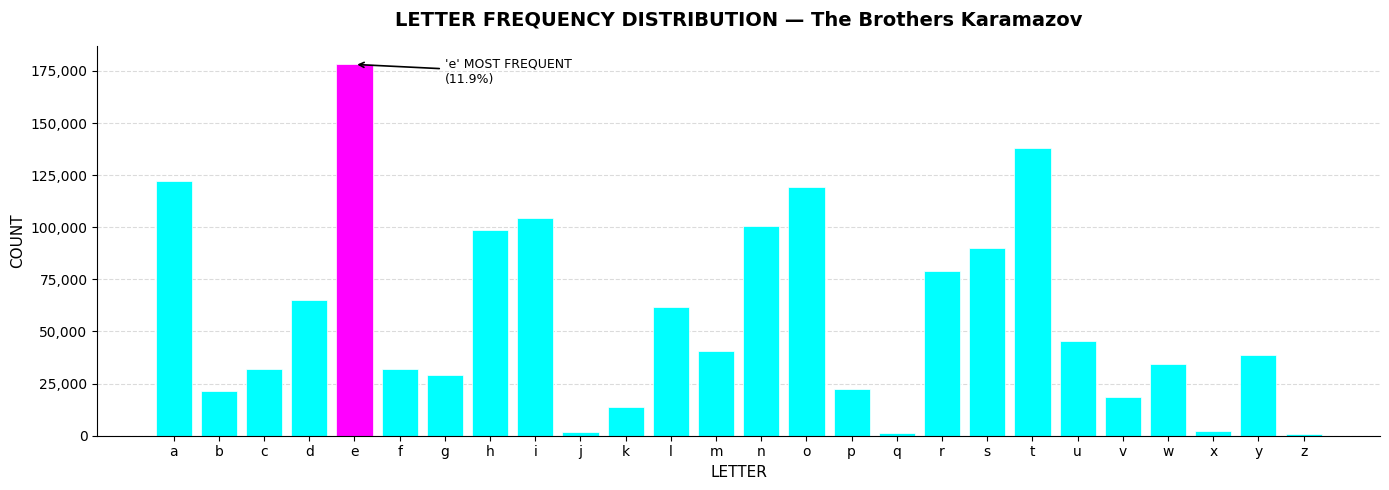

Saved: letter_frequencies.png


In [21]:
# LETTER FREQUENCY VISUALIZATION
# GENERATING A BAR CHART OF LETTER DISTRIBUTIONS ACROSS THE FULL ALPHABET
# WHY:
# 1. VISUAL REPRESENTATION MAKES FREQUENCY PATTERNS IMMEDIATELY APPARENT
# 2. ALLOWS DIRECT COMPARISON AGAINST KNOWN ENGLISH LETTER DISTRIBUTIONS

# BUILDING ORDERED LISTS OF ALL 26 LETTERS AND THEIR COUNTS
# ORDER IS ALPHABETICAL (a–z) TO MATCH X-AXIS LAYOUT
letters = list(string.ascii_lowercase)
counts = [letterCounts[l] for l in letters]

# IDENTIFYING THE SINGLE MOST FREQUENT LETTER FOR VISUAL CALLOUT
# max() WITH key=letterCounts.get RETURNS THE LETTER (KEY) WITH HIGHEST COUNT (VALUE)
topLetter = max(letterCounts, key=letterCounts.get)

# BUILDING A COLOR LIST: HIGHLIGHT MOST FREQUENT LETTER IN MAGENTA
# ALL OTHER BARS USE CYAN TO CREATE OBVIOUS VISUAL CONTRAST
# WHY: DRAWS THE READER'S ATTENTION DIRECTLY TO THE DOMINANT LETTER
colors = ['magenta' if l == topLetter else 'cyan' for l in letters]

# INITIALIZING FIGURE AND AXES WITH WIDE ASPECT RATIO
# WHY: 26 BARS ACROSS THE ALPHABET FIT MORE NATURALLY IN A WIDE LAYOUT
fig, ax = plt.subplots(figsize=(14, 5))

# PLOTTING VERTICAL BAR CHART
# edgecolor='white' CREATES SUBTLE SEPARATION BETWEEN ADJACENT BARS
ax.bar(letters, counts, color=colors, edgecolor='white', linewidth=0.5)

# SETTING CHART TITLE AND AXIS LABELS
# f-STRING EMBEDS NOVEL TITLE FOR FULL TRACEABILITY
ax.set_title(f"LETTER FREQUENCY DISTRIBUTION — {NOVEL_TITLE}",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("LETTER", fontsize=11)
ax.set_ylabel("COUNT", fontsize=11)

# FORMATTING Y-AXIS TICK LABELS WITH COMMA SEPARATORS
# WHY: LARGE COUNTS (E.G., 250,000) ARE UNREADABLE WITHOUT FORMATTING
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# PLACING GRIDLINES BEHIND BARS SO THEY DON'T OBSCURE DATA
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.45)

# REMOVING TOP AND RIGHT SPINES FOR A CLEANER, MODERN LOOK
# WHY: REDUCES CHART JUNK; FOCUSES ATTENTION ON DATA
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ADDING AN ANNOTATED ARROW CALLOUT TO THE MOST FREQUENT LETTER
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(
    f"'{topLetter}' MOST FREQUENT\n({letterProps[topLetter]*100:.1f}%)",
    xy=(letters.index(topLetter), letterCounts[topLetter]),
    xytext=(letters.index(topLetter) + 2, letterCounts[topLetter] * 0.95),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=9, color='black'
)

# APPLYING TIGHT LAYOUT TO PREVENT LABEL CLIPPING
plt.tight_layout()

# SAVING FIGURE TO DISK AT HIGH DPI FOR REPORT INCLUSION
# bbox_inches='tight' ENSURES NO LABELS ARE CUT OFF AT EDGES
plt.savefig('letter_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: letter_frequencies.png")

In [22]:
# WORD FREQUENCY COUNTING (POST-STOPWORD REMOVAL)
# BUILDING A RANKED LIST OF THE 40 MOST COMMON CONTENT WORDS
# WHY:
# 1. WORD FREQUENCY IS THE FOUNDATION OF BAG-OF-WORDS TEXT ANALYSIS
# 2. TOP WORDS REVEAL DOMINANT THEMES, CHARACTER NAMES, AND NARRATIVE FOCUS

def computeWordFreqs(tokens):
    """
    COUNTS WORD FREQUENCIES FROM A LIST OF FILTERED TOKENS USING Counter.
    ARGS:
        tokens (list[str]): POST-STOPWORD-REMOVAL TOKEN LIST
    RETURNS:
        Counter: MAPPING OF word -> count; CALL .most_common(k) TO GET SORTED RESULTS
    BIG-O: O(n) WHERE n = NUMBER OF TOKENS — SINGLE PASS THROUGH THE LIST
    """
    # Counter ITERATES THROUGH ALL TOKENS ONCE AND TALLIES OCCURRENCES
    # WHY: MORE EFFICIENT THAN A MANUAL DICT WITH CONDITIONAL UPDATES
    return Counter(tokens)

# APPLYING FREQUENCY COUNTER TO FULLY FILTERED TOKEN LIST
wordFreq = computeWordFreqs(cleanTokens)

# EXTRACTING TOP 40 MOST COMMON WORDS
# most_common(k) RETURNS A LIST OF (word, count) TUPLES IN DESCENDING ORDER
# BIG-O: O(nlogn) — INTERNALLY USES A HEAP FOR PARTIAL SORT
top40  = wordFreq.most_common(40)

# TOTAL FILTERED TOKEN COUNT — USED AS DENOMINATOR FOR PROPORTIONS
totalWords = len(cleanTokens)

# PRINTING CORPUS-LEVEL SUMMARY STATISTICS
print(f"TOTAL FILTERED TOKENS: {totalWords:,}")
print(f"UNIQUE VOCABULARY:     {len(wordFreq):,}\n")

# PRINTING RANKED FREQUENCY TABLE WITH ALIGNED COLUMNS
# :<6  → LEFT-JUSTIFIED IN 6-CHAR FIELD (RANK)
# :<22 → LEFT-JUSTIFIED IN 22-CHAR FIELD (WORD)
# :<10 → LEFT-JUSTIFIED IN 10-CHAR FIELD (COUNT)
print(f"{'RANK':<6} {'WORD':<22} {'COUNT':<10} {'PROPORTION'}")
print("─" * 50)
for rank, (word, count) in enumerate(top40, 1):
    # COMPUTING PROPORTION OF EACH WORD RELATIVE TO TOTAL FILTERED TOKENS
    # WHY: NORMALIZES COUNTS — USEFUL COMPARING TEXTS OF DIFFERENT LENGTHS
    print(f"{rank:<6} {word:<22} {count:<10,} {count/totalWords*100:.3f}%")

TOTAL FILTERED TOKENS: 158,271
UNIQUE VOCABULARY:     11,848

RANK   WORD                   COUNT      PROPORTION
──────────────────────────────────────────────────
1      one                    1,604      1.013%
2      alyosha                1,245      0.787%
3      would                  1,102      0.696%
4      said                   996        0.629%
5      mitya                  923        0.583%
6      man                    911        0.576%
7      know                   847        0.535%
8      though                 836        0.528%
9      father                 820        0.518%
10     come                   776        0.490%
11     ivan                   718        0.454%
12     time                   678        0.428%
13     like                   670        0.423%
14     could                  659        0.416%
15     even                   652        0.412%
16     go                     621        0.392%
17     see                    607        0.384%
18     suddenly    

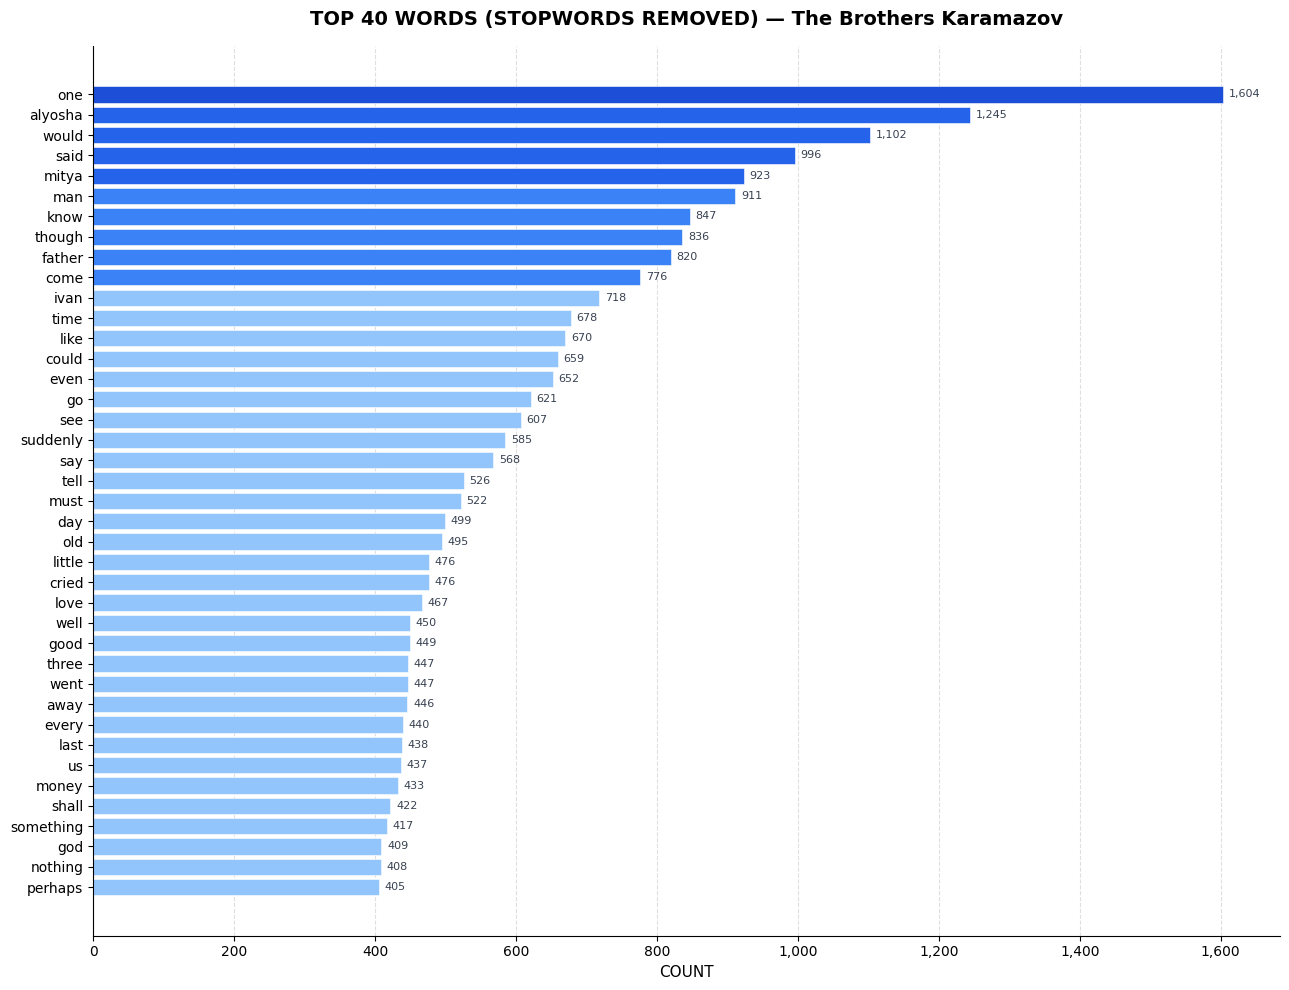

Saved: word_frequencies.png


In [23]:
# WORD FREQUENCY VISUALIZATION — HORIZONTAL BAR CHART
# VISUALIZING THE 40 MOST FREQUENT CONTENT WORDS AS A RANKED BAR CHART
# WHY:
# 1. HORIZONTAL LAYOUT ACCOMMODATES WORD LABELS WITHOUT ROTATION
# 2. RANKED ORDERING MAKES RELATIVE FREQUENCY DIFFERENCES IMMEDIATELY VISIBLE

# UNPACKING TOP-40 LIST OF (word, count) TUPLES INTO SEPARATE SEQUENCES
# zip(*top40) TRANSPOSES A LIST OF PAIRS INTO TWO PARALLEL TUPLES
wordsTop40, countsTop40 = zip(*top40)

# INITIALIZING FIGURE — TALL ASPECT RATIO TO ACCOMMODATE 40 HORIZONTAL BARS
fig, ax = plt.subplots(figsize=(13, 10))

# BUILDING A COLOR PALETTE THAT DARKENS PROPORTIONALLY WITH RANK
# → RANK 1      : DARKEST BLUE  (#1D4ED8) — HIGHEST FREQUENCY
# → RANKS 2–5   : MEDIUM-DARK BLUE (#2563EB)
# → RANKS 6–10  : MEDIUM BLUE (#3B82F6)
# → RANKS 11–40 : LIGHTEST BLUE (#93C5FD)
# WHY: VISUAL ENCODING OF RANK REDUCES NEED TO READ EVERY LABEL
palette = ['#1D4ED8'] * 1 + ['#2563EB'] * 4 + ['#3B82F6'] * 5 + ['#93C5FD'] * 30

# PLOTTING HORIZONTAL BARS IN REVERSED ORDER SO RANK 1 APPEARS AT THE TOP
# list(reversed(...)) FLIPS BOTH SEQUENCES CONSISTENTLY
# WHY: NATURAL READING DIRECTION — HIGHEST VALUE FIRST
ax.barh(
    list(reversed(wordsTop40)),
    list(reversed(countsTop40)),
    color=list(reversed(palette)),
    edgecolor='white', linewidth=0.4
)

# SETTING TITLE AND AXIS LABEL
ax.set_title(f"TOP 40 WORDS (STOPWORDS REMOVED) — {NOVEL_TITLE}",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("COUNT", fontsize=11)

# FORMATTING X-AXIS WITH COMMA SEPARATORS FOR LARGE COUNTS
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# PLACING GRIDLINES BEHIND BARS
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

# REMOVING DECORATIVE SPINES FOR CLEANER APPEARANCE
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ADDING INLINE COUNT LABELS AT THE END OF EACH BAR
# WHY: ALLOWS EXACT VALUE READING WITHOUT REQUIRING GRIDLINE ESTIMATION
# OFFSET = 0.5% OF MAX VALUE → SMALL CONSISTENT GAP FROM BAR TIP
for i, (word, count) in enumerate(zip(reversed(wordsTop40), reversed(countsTop40))):
    ax.text(count + max(countsTop40) * 0.005, i, f"{count:,}",
            va='center', fontsize=8, color='#374151')

plt.tight_layout()
plt.savefig('word_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: word_frequencies.png")

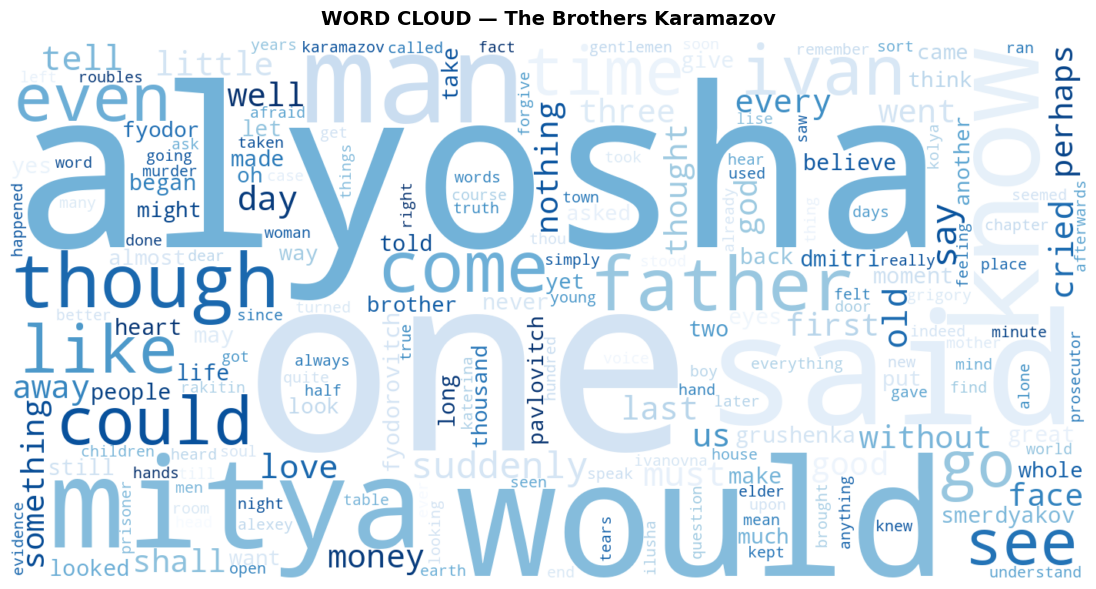

SAVED: word_cloud_words.png


In [24]:
# WORD CLOUD VISUALIZATION
# GENERATING A WORD CLOUD WHERE FONT SIZE IS PROPORTIONAL TO WORD FREQUENCY
# WHY:
# 1. PROVIDES AN INTUITIVE QUALITATIVE SNAPSHOT OF THE MOST PROMINENT VOCABULARY
# 2. COMPLEMENTS THE BAR CHART BY EMPHASIZING RELATIVE SCALE AT A GLANCE

def generateWordCloud(freqDict, title, filename, colormap='Blues'):
    """
    GENERATES AND SAVES A WORD CLOUD FROM A WORD FREQUENCY DICTIONARY.
    FONT SIZE OF EACH WORD IS PROPORTIONAL TO ITS FREQUENCY.
    ARGS:
        freqDict (dict): WORD → FREQUENCY MAPPING
        title    (str):  PLOT TITLE STRING
        filename (str):  OUTPUT .png FILENAME
        colormap (str):  MATPLOTLIB COLORMAP NAME FOR WORD COLORING
    RETURNS:
        None — DISPLAYS AND SAVES THE FIGURE TO DISK
    BIG-O: O(nlogn) WHERE n = UNIQUE VOCABULARY SIZE (INTERNAL LAYOUT SORT)
    """
    # CONFIGURING WORD CLOUD GENERATOR
    # width/height  - OUTPUT RESOLUTION IN PIXELS
    # max_words     - CAPS DISPLAYED VOCABULARY TO AVOID VISUAL CLUTTER
    # min_font_size - PREVENTS RARE WORDS FROM BEING RENDERED UNREADABLY SMALL
    # collocations=False - PREVENTS DUPLICATE BIGRAMS FROM APPEARING ALONGSIDE UNIGRAMS
    wc = WordCloud(
        width=1400, height=700,
        background_color='white',
        colormap=colormap,
        max_words=200,
        min_font_size=8,
        collocations=False
    ).generate_from_frequencies(freqDict)
    # generate_from_frequencies() ACCEPTS A {word: count} DICT DIRECTLY
    # WHY: MORE PRECISE THAN generate() WHICH RE-TOKENIZES A RAW STRING

    # RENDERING WORD CLOUD ONTO MATPLOTLIB FIGURE
    fig, ax = plt.subplots(figsize=(14, 6))

    # imshow() DISPLAYS THE CLOUD AS A RASTER IMAGE
    # interpolation='bilinear' -> SMOOTHS PIXEL EDGES FOR CLEANER APPEARANCE
    ax.imshow(wc, interpolation='bilinear')

    # DISABLING AXES — NO TICKS OR SPINES ARE MEANINGFUL FOR AN IMAGE PLOT
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# CALLING WORD CLOUD GENERATOR WITH FULL FILTERED WORD FREQUENCY DICT
# dict(wordFreq) CONVERTS Counter OBJECT TO PLAIN DICT (REQUIRED BY WordCloud)
generateWordCloud(
    dict(wordFreq),
    f"WORD CLOUD — {NOVEL_TITLE}",
    'word_cloud_words.png',
    colormap='Blues'
)
print("SAVED: word_cloud_words.png")

In [25]:
# BIG-O COMPLEXITY ANALYSIS AND LETTER DISTRIBUTION INTERPRETATION
# DOCUMENTING THE THEORETICAL TIME AND SPACE COMPLEXITY OF THE FULL Q2 PIPELINE
# WHY:
# 1. ALGORITHMIC ANALYSIS IS A CORE GRADING CRITERION FOR THIS PROJECT
# 2. DEMONSTRATES UNDERSTANDING OF HOW PERFORMANCE SCALES WITH INPUT SIZE

# VARIABLE DEFINITIONS USED THROUGHOUT THE ANALYSIS:
# n = NUMBER OF CHARACTERS IN THE RAW TEXT (INPUT SIZE FOR CHAR-LEVEL OPERATIONS)
# w = NUMBER OF TOKENS AFTER TOKENIZATION (INPUT SIZE FOR TOKEN-LEVEL OPERATIONS)
# v = UNIQUE VOCABULARY SIZE (UPPER BOUND ON COUNTER DICTIONARY SIZE)
# s = STOPWORD SET SIZE — CONSTANT ≈ 179 FOR NLTK ENGLISH -> TREATED AS O(1)

print(f"""
BIG-O COMPLEXITY — Q2 PREPROCESSING & COUNTING

Let:
  n = NUMBER OF CHARS IN RAW TEXT
  w = NUMBER OF TOKENS AFTER TOKENIZATION
  v = SIZE OF UNIQUE VOCABULARY
  s = STOPWORD SET SIZE (~179 FOR NLTK ENGLISH)

PREPROCESSING PIPELINE:
  toLower(text)                 O(n)      SINGLE PASS OVER ALL CHARS
  removePunctuation(text)       O(n)      REGEX ENGINE SCANS EACH CHAR ONCE
  tokenize(text)                O(n)      str.split() IS A SINGLE LINEAR SCAN
  removeStopwords(tokens)       O(w)      SET LOOKUP IS O(1) PER TOKEN
  ─────────────────────────────────────────────────────────
  FULL PIPELINE                 O(n)      DOMINATED BY CHAR-LEVEL PASSES

COUNTING:
  computeLetterFreqs(text)      O(n)      SINGLE PASS OVER ALL CHARS
  computeWordFreqs(tokens)      O(w)      SINGLE PASS OVER TOKEN LIST
  Counter.most_common(k)        O(wlogw)  HEAPQ-BASED PARTIAL SORT INTERNALLY

SPACE COMPLEXITY:
  TOKEN LIST (rawTokens)        O(w)      STORES ALL TOKENS BEFORE FILTERING
  LETTER COUNTER                O(26)=O(1) FIXED ALPHABET - CONSTANT SIZE
  WORD COUNTER                  O(v)      ONE ENTRY PER UNIQUE VOCAB TERM
  ─────────────────────────────────────────────────────────
  DOMINANT SPACE TERM:          O(w) ≈ O(n) IN PRACTICE

INTERPRETATION — LETTER DISTRIBUTION:
  THE MOST FREQUENT LETTER IN {NOVEL_TITLE} IS
  '{max(letterCounts, key=letterCounts.get).upper()}'
  ({letterProps[max(letterCounts, key=letterCounts.get)]*100:.2f}% OF ALL LETTERS), CONSISTENT WITH KNOWN ENGLISH FREQUENCY TABLES WHERE E, T, A, O, I, N, ARE THE TOP-RANKING LETTERS. THE DISTRIBUTION CLOSELY MIRRORS THE ZIPF-LIKE PATTERN EXPECTED FOR ENGLISH PROSE; A SMALL SET OF LETTERS ACCOUNTS FOR THE MAJORITY OF CHARACTERS. LOW FREQUENCY LETTERS (Q, X, Z) APPEAR RARELY, AS EXPECTED IN A TRANSLATED 19TH CENTURY RUSSIAN NOVEL WHERE NAMES AND VOCABULARY SKEW TOWARD COMMON LATIN-ALPHABET PATTERNS.
""")


BIG-O COMPLEXITY — Q2 PREPROCESSING & COUNTING

Let:
  n = NUMBER OF CHARS IN RAW TEXT
  w = NUMBER OF TOKENS AFTER TOKENIZATION
  v = SIZE OF UNIQUE VOCABULARY
  s = STOPWORD SET SIZE (~179 FOR NLTK ENGLISH)

PREPROCESSING PIPELINE:
  toLower(text)                 O(n)      SINGLE PASS OVER ALL CHARS
  removePunctuation(text)       O(n)      REGEX ENGINE SCANS EACH CHAR ONCE
  tokenize(text)                O(n)      str.split() IS A SINGLE LINEAR SCAN
  removeStopwords(tokens)       O(w)      SET LOOKUP IS O(1) PER TOKEN
  ─────────────────────────────────────────────────────────
  FULL PIPELINE                 O(n)      DOMINATED BY CHAR-LEVEL PASSES

COUNTING:
  computeLetterFreqs(text)      O(n)      SINGLE PASS OVER ALL CHARS
  computeWordFreqs(tokens)      O(w)      SINGLE PASS OVER TOKEN LIST
  Counter.most_common(k)        O(wlogw)  HEAPQ-BASED PARTIAL SORT INTERNALLY

SPACE COMPLEXITY:
  TOKEN LIST (rawTokens)        O(w)      STORES ALL TOKENS BEFORE FILTERING
  LETTER COUNT

In [26]:
# BIGRAM GENERATION USING SLIDING WINDOW APPROACH
# A BIGRAM IS A SEQUENCE OF TWO CONSECUTIVE TOKENS
# EXAMPLE: "data science is great" → ["data science", "science is", "is great"]
# WHY:
# 1. CAPTURES CO-OCCURRENCE PATTERNS BETWEEN ADJACENT WORDS
# 2. REVEALS COMMON TWO-WORD PHRASES AND THEMATIC PAIRINGS IN THE TEXT

def computeBigrams(tokens):
    """
    GENERATES ALL BIGRAMS FROM A TOKEN LIST USING A SLIDING WINDOW OF SIZE 2
    AND RETURNS THEIR FREQUENCY COUNTS.
    ARGS:
        tokens (list[str]): CLEANED, FILTERED TOKEN LIST (POST-STOPWORD REMOVAL)
    RETURNS:
        Counter: MAPPING OF bigram_string -> count, e.g. {"ivan karamazov": 42}
    BIG-O: O(w) WHERE w = NUMBER OF TOKENS — SINGLE PASS VIA zip()
    """
    # SLIDING WINDOW: zip(tokens, tokens[1:]) PAIRS EACH TOKEN WITH ITS SUCCESSOR
    # JOINING TUPLE WITH SPACE PRODUCES A READABLE BIGRAM STRING
    # WHY: zip() IS MORE MEMORY-EFFICIENT THAN EXPLICIT INDEX LOOPING
    bigrams = [f"{a} {b}" for a, b in zip(tokens, tokens[1:])]
    return Counter(bigrams)


# APPLYING BIGRAM FUNCTION TO CLEANED TOKEN LIST
bigramCounts = computeBigrams(cleanTokens)

# EXTRACTING TOP 20 MOST FREQUENT BIGRAMS
# BIG-O: O(w log k) WHERE k=20 — heapq.nlargest INTERNALLY
top20Bigrams = bigramCounts.most_common(20)

# PRINTING RANKED BIGRAM FREQUENCY TABLE
print(f"TOTAL UNIQUE BIGRAMS: {len(bigramCounts):,}\n")
print(f"{'RANK':<6} {'BIGRAM':<35} {'COUNT':<10} {'PROPORTION'}")
print("─" * 60)
for rank, (bigram, count) in enumerate(top20Bigrams, 1):
    proportion = count / len(cleanTokens) * 100
    print(f"{rank:<6} {bigram:<35} {count:<10,} {proportion:.4f}%")

TOTAL UNIQUE BIGRAMS: 124,535

RANK   BIGRAM                              COUNT      PROPORTION
────────────────────────────────────────────────────────────
1      fyodor pavlovitch                   300        0.1895%
2      every one                           219        0.1384%
3      old man                             207        0.1308%
4      katerina ivanovna                   199        0.1257%
5      three thousand                      175        0.1106%
6      dmitri fyodorovitch                 170        0.1074%
7      alexey fyodorovitch                 113        0.0714%
8      nikolay parfenovitch                103        0.0651%
9      father zossima                      97         0.0613%
10     madame hohlakov                     93         0.0588%
11     pyotr ilyitch                       91         0.0575%
12     said alyosha                        88         0.0556%
13     young man                           84         0.0531%
14     mi sov                        

In [27]:
# TRIGRAM GENERATION USING SLIDING WINDOW APPROACH
# A TRIGRAM IS A SEQUENCE OF THREE CONSECUTIVE TOKENS
# EXAMPLE: "data science is great" → ["data science is", "science is great"]
# WHY:
# 1. CAPTURES RICHER PHRASE STRUCTURE THAN BIGRAMS
# 2. SURFACES THREE-WORD EXPRESSIONS AND RECURRING NARRATIVE PATTERNS

def computeTrigrams(tokens):
    """
    GENERATES ALL TRIGRAMS FROM A TOKEN LIST USING A SLIDING WINDOW OF SIZE 3
    AND RETURNS THEIR FREQUENCY COUNTS.
    ARGS:
        tokens (list[str]): CLEANED, FILTERED TOKEN LIST (POST-STOPWORD REMOVAL)
    RETURNS:
        Counter: MAPPING OF trigram_string -> count, e.g. {"father ivan alyosha": 12}
    BIG-O: O(w) WHERE w = NUMBER OF TOKENS — SINGLE PASS VIA zip()
    """
    # SLIDING WINDOW OF SIZE 3: zip(tokens, tokens[1:], tokens[2:])
    # EACH ITERATION YIELDS A (word1, word2, word3) TUPLE
    # WHY: SAME EFFICIENT zip() PATTERN AS BIGRAMS, EXTENDED BY ONE POSITION
    trigrams = [f"{a} {b} {c}" for a, b, c in zip(tokens, tokens[1:], tokens[2:])]
    return Counter(trigrams)


# APPLYING TRIGRAM FUNCTION TO CLEANED TOKEN LIST
trigramCounts = computeTrigrams(cleanTokens)

# EXTRACTING TOP 20 MOST FREQUENT TRIGRAMS
top20Trigrams = trigramCounts.most_common(20)

# PRINTING RANKED TRIGRAM FREQUENCY TABLE
print(f"TOTAL UNIQUE TRIGRAMS: {len(trigramCounts):,}\n")
print(f"{'RANK':<6} {'TRIGRAM':<45} {'COUNT':<10} {'PROPORTION'}")
print("─" * 70)
for rank, (trigram, count) in enumerate(top20Trigrams, 1):
    proportion = count / len(cleanTokens) * 100
    print(f"{rank:<6} {trigram:<45} {count:<10,} {proportion:.4f}%")

TOTAL UNIQUE TRIGRAMS: 154,973

RANK   TRIGRAM                                       COUNT      PROPORTION
──────────────────────────────────────────────────────────────────────
1      father pa ssy                                 72         0.0455%
2      three thousand roubles                        45         0.0284%
3      adela da ivanovna                             14         0.0088%
4      two hundred roubles                           14         0.0088%
5      fifteen hundred roubles                       14         0.0088%
6      cried fyodor pavlovitch                       13         0.0082%
7      hid face hands                                12         0.0076%
8      father fyodor pavlovitch                      11         0.0070%
9      hundred rouble notes                          11         0.0070%
10     dear alexey fyodorovitch                      11         0.0070%
11     cried madame hohlakov                         9          0.0057%
12     fyodor pavlovitch karam

In [28]:
# SENTENCE STRUCTURE METRICS
# COMPUTING AVERAGE WORD COUNT PER SENTENCE AND SENTENCE LENGTH DISTRIBUTION
# WHY:
# 1. SENTENCE-LEVEL ANALYSIS REVEALS AUTHORIAL STYLE AND PROSE COMPLEXITY
# 2. COMPLEMENTS WORD/LETTER ANALYSIS WITH STRUCTURAL LINGUISTIC PATTERNS

def computeSentenceMetrics(text):
    """
    COMPUTES SENTENCE-LEVEL STRUCTURAL METRICS FROM RAW TEXT INCLUDING
    AVERAGE WORDS PER SENTENCE, SENTENCE LENGTH DISTRIBUTION, AND
    MOST COMMON SENTENCE STARTERS.
    ARGS:
        text (str): RAW NOVEL TEXT (BEFORE ANY PREPROCESSING)
    RETURNS:
        tuple:
            sentences      (list[str]): LIST OF INDIVIDUAL SENTENCE STRINGS
            wordCounts     (list[int]): WORD COUNT PER SENTENCE
            avgWords       (float):     MEAN WORDS PER SENTENCE
            starterCounts  (Counter):   FREQUENCY OF FIRST WORDS
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS — SINGLE REGEX PASS TO SPLIT,
           THEN O(s) WHERE s = NUMBER OF SENTENCES FOR DOWNSTREAM COUNTING
    """
    # SPLITTING RAW TEXT INTO SENTENCES ON TERMINAL PUNCTUATION
    # re.split() ON [.!?]+ HANDLES ELLIPSES AND MULTIPLE PUNCTUATION MARKS
    # WHY: SIMPLE RULE-BASED SPLITTING WITHOUT REQUIRING NLP LIBRARIES
    rawSentences = re.split(r'[.!?]+', text)

    # STRIPPING WHITESPACE AND FILTERING OUT EMPTY OR NEAR-EMPTY FRAGMENTS
    # THRESHOLD OF > 2 WORDS EXCLUDES HEADERS, PAGE NUMBERS, AND ARTIFACTS
    # WHY: GUTENBERG FILES CONTAIN CHAPTER HEADINGS THAT ARE NOT TRUE SENTENCES
    sentences = [s.strip() for s in rawSentences if len(s.split()) > 2]

    # COMPUTING WORD COUNT FOR EACH SENTENCE
    # str.split() ON DEFAULT WHITESPACE IS CONSISTENT WITH TOKENIZER BEHAVIOR
    wordCounts = [len(s.split()) for s in sentences]

    # MEAN WORDS PER SENTENCE — CORE READABILITY METRIC
    avgWords = sum(wordCounts) / len(wordCounts)

    # EXTRACTING FIRST WORD OF EACH SENTENCE AS THE SENTENCE STARTER
    # LOWERCASED FOR CONSISTENT COUNTING (E.G., "The" AND "the" → SAME KEY)
    # WHY: COMMON STARTERS REVEAL SYNTACTIC PREFERENCES OF THE AUTHOR
    starters = [s.split()[0].lower() for s in sentences if s.split()]
    starterCounts = Counter(starters)

    return sentences, wordCounts, avgWords, starterCounts


# APPLYING SENTENCE METRICS TO RAW (UNPROCESSED) TEXT
# WHY: PUNCTUATION IS REQUIRED FOR SENTENCE SPLITTING — MUST USE rawText
sentences, wordCounts, avgWords, starterCounts = computeSentenceMetrics(rawText)

# ── SUMMARY STATISTICS ───────────────────────────────────────
print("SENTENCE STRUCTURE METRICS")
print("─" * 45)
print(f"  TOTAL SENTENCES DETECTED:   {len(sentences):>10,}")
print(f"  AVERAGE WORDS PER SENTENCE: {avgWords:>10.2f}")
print(f"  SHORTEST SENTENCE (WORDS):  {min(wordCounts):>10,}")
print(f"  LONGEST SENTENCE (WORDS):   {max(wordCounts):>10,}")
print(f"  MEDIAN SENTENCE LENGTH:     {sorted(wordCounts)[len(wordCounts)//2]:>10,}")

# ── TOP 10 SENTENCE STARTERS ─────────────────────────────────
print("\nTOP 10 SENTENCE STARTERS:")
print(f"{'RANK':<6} {'WORD':<20} {'COUNT'}")
print("─" * 35)
for rank, (word, count) in enumerate(starterCounts.most_common(10), 1):
    print(f"{rank:<6} {word:<20} {count:,}")

# ── LENGTH DISTRIBUTION BUCKETS ──────────────────────────────
# GROUPING SENTENCE LENGTHS INTO BUCKETS FOR TABULAR DISPLAY
buckets = {
    "1-5 words":    sum(1 for w in wordCounts if 1  <= w <= 5),
    "6-15 words":   sum(1 for w in wordCounts if 6  <= w <= 15),
    "16-30 words":  sum(1 for w in wordCounts if 16 <= w <= 30),
    "31-50 words":  sum(1 for w in wordCounts if 31 <= w <= 50),
    "51+ words":    sum(1 for w in wordCounts if w  >= 51),
}
print("\nSENTENCE LENGTH DISTRIBUTION:")
print(f"{'BUCKET':<18} {'COUNT':<10} {'PROPORTION'}")
print("─" * 40)
for bucket, cnt in buckets.items():
    print(f"{bucket:<18} {cnt:<10,} {cnt/len(wordCounts)*100:.1f}%")

SENTENCE STRUCTURE METRICS
─────────────────────────────────────────────
  TOTAL SENTENCES DETECTED:       24,294
  AVERAGE WORDS PER SENTENCE:      14.54
  SHORTEST SENTENCE (WORDS):           3
  LONGEST SENTENCE (WORDS):          163
  MEDIAN SENTENCE LENGTH:             11

TOP 10 SENTENCE STARTERS:
RANK   WORD                 COUNT
───────────────────────────────────
1      ”                    4,177
2      i                    1,631
3      he                   1,494
4      but                  1,009
5      and                  962
6      the                  900
7      you                  467
8      ’                    466
9      it                   462
10     she                  351

SENTENCE LENGTH DISTRIBUTION:
BUCKET             COUNT      PROPORTION
────────────────────────────────────────
1-5 words          4,503      18.5%
6-15 words         11,614     47.8%
16-30 words        5,987      24.6%
31-50 words        1,796      7.4%
51+ words          394        1.6%


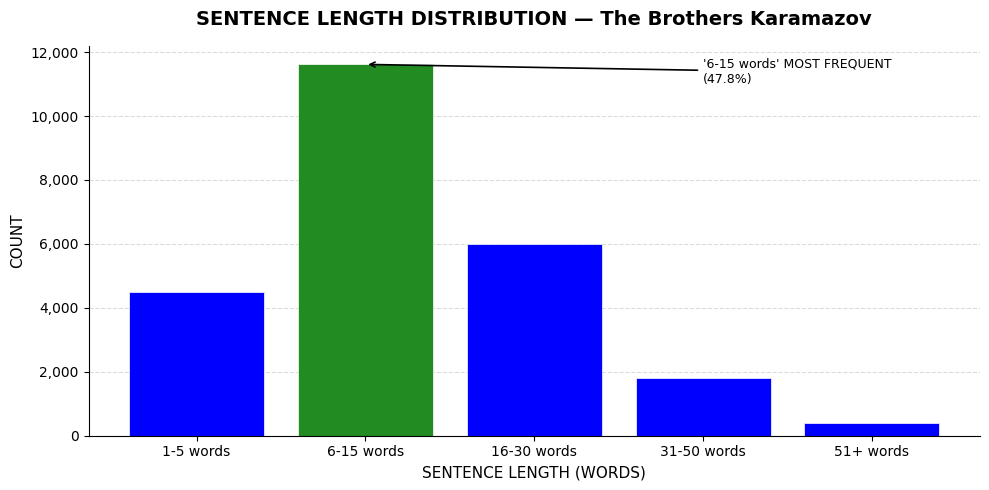

Saved: Sentence_length_distribution.png


In [30]:
# SENTENCE STRUCTURE VISUALIZATION
# GENERATING A BAR CHART OF SENTENCE STRUCTURE METRICS FROM THE BUCKET
# WHY:
# 1. VISUAL REPRESENTATION MAKES FREQUENCY PATTERNS IMMEDIATELY APPARENT
# 2. ALLOWS DIRECT COMPARISON FOR THE SENTENCE LENGTH DISTRIBUTIONS

# GETTING LISTS OF BUCKETS LABELS AND THEIR COUNTS
# ORDER MATCHES ONE FROM BUCKETS DICTIONARY TO MATCH X-AXIS LAYOUT
labels = list(buckets.keys())
counts = list(buckets.values())

# IDENTIFYING THE MOST FREQUENT AVERAGE WORDS PER SENTENCE FOR VISUAL CALLOUT
# max() WITH key=buckets.get RETURNS THE MOST FREQUENT AVERAGE WORDS PER SENTENCE
# (KEY) WITH HIGHEST COUNT (VALUE)
topBucket = max(labels, key=buckets.get)

# BUILDING A COLOR LIST: HIGHLIGHT MOST FREQUENT SENTENCE STURCTURE IN FORESTGREEN
# ALL OTHER BARS USE BLUE TO CREATE OBVIOUS VISUAL CONTRAST
# WHY: DRAWS THE READER'S ATTENTION DIRECTLY TO THE DOMINANT LENGTH BUCKET
colors = ['forestgreen' if b == topBucket else 'blue' for b in labels]

# INITIALIZING FIGURE AND AXES WITH BALANCED ASPECT RATIO
# WHY: ALLOWS THE BUCKET LABELS TO BE SEEN CLEARLY
fig, ax = plt.subplots(figsize=(10, 5))

# PLOTTING VERTICAL BAR CHART
# edgecolor='white' CREATES SUBTLE SEPARATION BETWEEN ADJACENT BARS
ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=0.5)

# SETTING CHART TITLE AND AXIS LABELS
# f-STRING EMBEDS NOVEL TITLE FOR FULL TRACEABILITY
ax.set_title(f"SENTENCE LENGTH DISTRIBUTION — {NOVEL_TITLE}",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("SENTENCE LENGTH (WORDS)", fontsize=11)
ax.set_ylabel("COUNT", fontsize=11)

# FORMATTING Y-AXIS TICK LABELS WITH COMMA SEPARATORS
# WHY: LARGE COUNTS (E.G., 250,000) ARE UNREADABLE WITHOUT FORMATTING
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# PLACING GRIDLINES BEHIND BARS SO THEY DON'T OBSCURE DATA
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.45)

# REMOVING TOP AND RIGHT SPINES FOR A CLEANER, MODERN LOOK
# WHY: REDUCES CHART JUNK; FOCUSES ATTENTION ON DATA
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ADDING AN ANNOTATED ARROW CALLOUT TO THE MOST FREQUENT SENTENCE STRUCTURE
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(
    f"'{topBucket}' MOST FREQUENT\n({buckets[topBucket]/ len(wordCounts)* 100:.1f}%)",
    xy=(labels.index(topBucket), buckets[topBucket]),
    xytext=(labels.index(topBucket) + 2, buckets[topBucket] * 0.95),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=9, color='black'
)

# APPLYING TIGHT LAYOUT TO PREVENT LABEL CLIPPING
plt.tight_layout()

# SAVING FIGURE TO DISK AT HIGH DPI FOR REPORT INCLUSION
# bbox_inches='tight' ENSURES NO LABELS ARE CUT OFF AT EDGES
plt.savefig('Sentence_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Sentence_length_distribution.png")

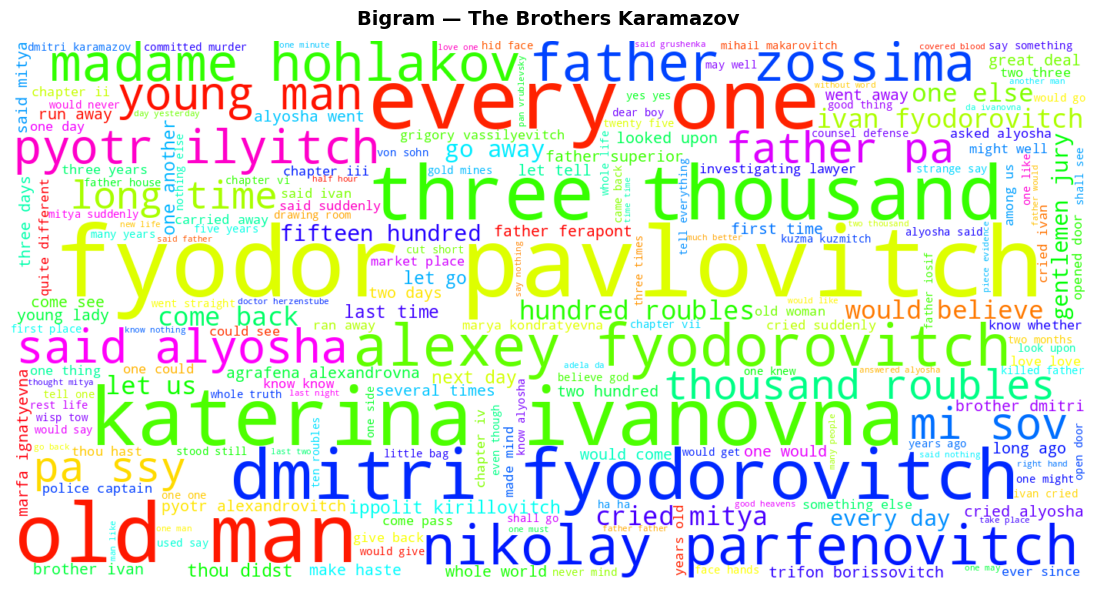

SAVED: word_cloud_bigrams.png


In [31]:
# Bigram Word Cloud
generateWordCloud(
    dict(bigramCounts),
    f"Bigram — {NOVEL_TITLE}",
    'word_cloud_words.png',
    colormap='gist_rainbow'
)
print("SAVED: word_cloud_bigrams.png")

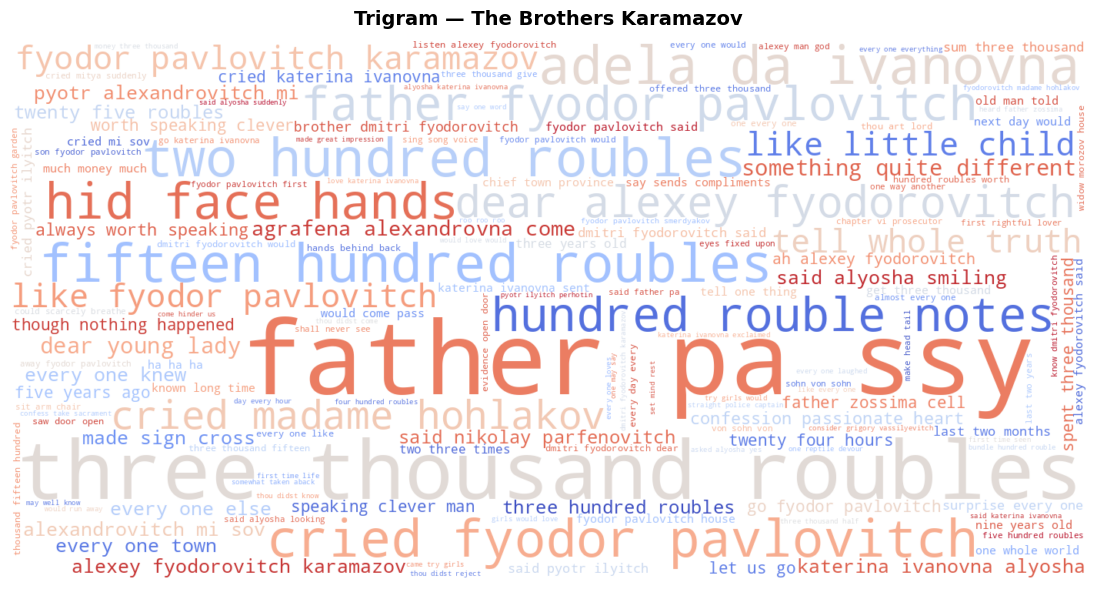

SAVED: word_cloud_trigrams.png


In [32]:
# Trigram Word Cloud
generateWordCloud(
    dict(trigramCounts),
    f"Trigram — {NOVEL_TITLE}",
    'word_cloud_words.png',
    colormap='coolwarm'
)
print("SAVED: word_cloud_trigrams.png")